Starting Heisenberg mean-field thin film simulation...


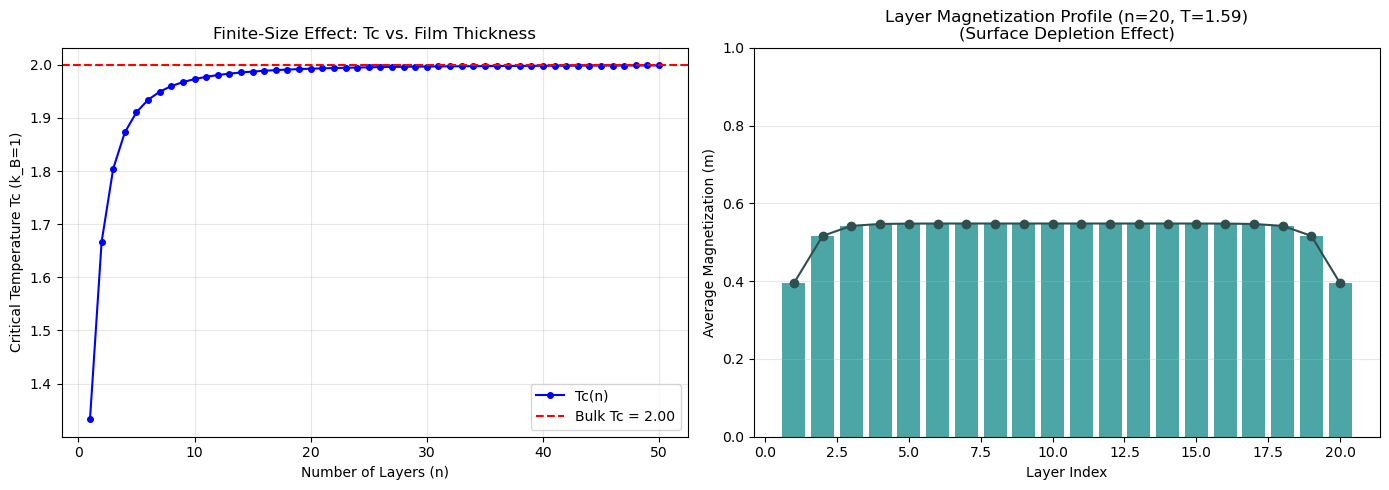

Simulation complete. Figure saved as 'heisenberg_simulation.png'.


In [4]:
import numpy as np
import matplotlib.pyplot as plt

def langevin(x):
    """
    Classical Langevin function L(x) = coth(x) - 1/x.
    Uses Taylor expansion near x=0 to avoid division by zero.
    """
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    
    # Small x approximation: L(x) ≈ x/3
    mask = np.abs(x) < 1e-5
    out[mask] = x[mask] / 3.0
    
    # Normal calculation
    out[~mask] = 1.0 / np.tanh(x[~mask]) - 1.0 / x[~mask]
    return out

def calc_Tc_n(n_layers, JH, JV):
    """Calculate phase transition temperature Tc(n) for finite layers."""
    return (4 * JH + 2 * JV * np.cos(np.pi / (n_layers + 1))) / 3.0

def calc_Tc_bulk(JH, JV):
    """Calculate phase transition temperature Tc(bulk) for infinite bulk."""
    return (4 * JH + 2 * JV) / 3.0

def solve_magnetization(n_layers, T, JH, JV, max_iter=1000, tol=1e-6):
    """
    Solve self-consistent equations iteratively to get the magnetization profile.
    """
    # Initialize magnetization (assuming a highly aligned ferromagnetic state)
    m = np.ones(n_layers) * 0.5 
    
    for _ in range(max_iter):
        m_old = np.copy(m)
        h_eff = np.zeros(n_layers)
        
        # Calculate effective field for each layer
        for i in range(n_layers):
            # 1. In-plane contribution
            h_eff[i] = 4 * JH * m[i]
            
            # 2. Out-of-plane contribution (open boundary conditions)
            if i > 0:
                h_eff[i] += JV * m[i-1]  # Contribution from the layer below
            if i < n_layers - 1:
                h_eff[i] += JV * m[i+1]  # Contribution from the layer above
        
        # Update magnetization (m = L(h/T)), assuming k_B = 1
        m = langevin(h_eff / T)
        
        # Check convergence condition
        if np.max(np.abs(m - m_old)) < tol:
            break
            
    return m

def run_simulation_and_plot():
    """Main function: run calculations and plot results."""
    # --- Physics Parameters ---
    JH = 1.0  # In-plane exchange coupling
    JV = 1.0  # Out-of-plane exchange coupling
    
    # --- Figure 1: Phase transition temperature Tc vs layer count n ---
    n_array = np.arange(1, 51)
    Tc_array = [calc_Tc_n(n, JH, JV) for n in n_array]
    Tc_bulk = calc_Tc_bulk(JH, JV)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(n_array, Tc_array, marker='o', markersize=4, linestyle='-', color='b', label='Tc(n)')
    ax1.axhline(Tc_bulk, color='r', linestyle='--', label=f'Bulk Tc = {Tc_bulk:.2f}')
    ax1.set_xlabel('Number of Layers (n)')
    ax1.set_ylabel('Critical Temperature Tc (k_B=1)')
    ax1.set_title('Finite-Size Effect: Tc vs. Film Thickness')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # --- Figure 2: Layer magnetization profile (Surface Depletion) ---
    target_n = 20
    target_Tc = calc_Tc_n(target_n, JH, JV)
    T_sim = target_Tc * 0.8  # Observe at 80% of the critical temperature
    
    m_profile = solve_magnetization(target_n, T_sim, JH, JV)
    layers = np.arange(1, target_n + 1)
    
    ax2.bar(layers, m_profile, color='teal', alpha=0.7)
    ax2.plot(layers, m_profile, marker='o', color='darkslategray')
    ax2.set_xlabel('Layer Index')
    ax2.set_ylabel('Average Magnetization (m)')
    ax2.set_title(f'Layer Magnetization Profile (n={target_n}, T={T_sim:.2f})\n(Surface Depletion Effect)')
    ax2.set_ylim(0, 1)
    ax2.grid(True, axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../plots_from_numerical_codes/heisenberg_simulation.png', dpi=300)
    plt.show()

if __name__ == "__main__":
    print("Starting Heisenberg mean-field thin film simulation...")
    run_simulation_and_plot()
    print("Simulation complete. Figure saved as 'heisenberg_simulation.png'.")

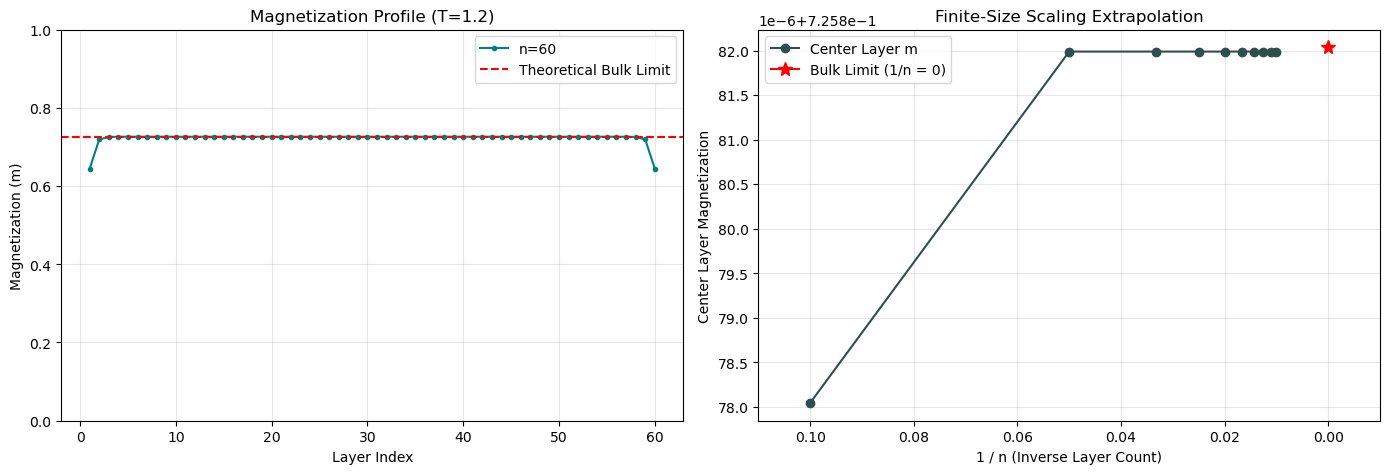

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os

def langevin(x):
    """Classical Langevin function L(x) = coth(x) - 1/x."""
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    
    # Taylor expansion for small x to avoid division by zero
    mask = np.abs(x) < 1e-5
    out[mask] = x[mask] / 3.0
    
    # Standard evaluation
    out[~mask] = 1.0 / np.tanh(x[~mask]) - 1.0 / x[~mask]
    return out

def solve_magnetization(n_layers, T, JH, JV, max_iter=2000, tol=1e-7):
    """
    Fixed-point iteration to find the magnetization profile of a finite thin film.
    """
    # Initialize with a strong ferromagnetic guess
    m = np.ones(n_layers) * 0.8 
    
    for _ in range(max_iter):
        m_old = np.copy(m)
        h_eff = np.zeros(n_layers)
        
        for i in range(n_layers):
            h_eff[i] = 4 * JH * m[i]
            if i > 0:
                h_eff[i] += JV * m[i-1]
            if i < n_layers - 1:
                h_eff[i] += JV * m[i+1]
                
        m = langevin(h_eff / T)
        
        if np.max(np.abs(m - m_old)) < tol:
            break
            
    return m

def solve_bulk_magnetization(T, JH, JV, max_iter=2000, tol=1e-7):
    """
    Fixed-point iteration to find the magnetization of an infinite bulk material.
    """
    m = 0.8
    for _ in range(max_iter):
        m_old = m
        # In bulk, all layers are equivalent: m^(a-1) = m^(a+1) = m^a
        h_eff = (4 * JH + 2 * JV) * m
        m = langevin(h_eff / T)
        
        if np.abs(m - m_old) < tol:
            break
            
    return m

def run_scaling_simulation():
    """Main function to perform finite-size scaling and plot results."""
    JH = 1.0
    JV = 1.0
    # Must choose a temperature below the bulk critical temperature (Tc_bulk = 2.0)
    T_sim = 1.2 
    
    # 1. Calculate the exact bulk limit at this temperature
    m_bulk = solve_bulk_magnetization(T_sim, JH, JV)
    
    # 2. Calculate profile for a specific thick film to show surface depletion
    n_thick = 60
    m_profile = solve_magnetization(n_thick, T_sim, JH, JV)
    
    # 3. Finite-size scaling data collection
    n_list = np.arange(10, 101, 10)
    inv_n_list = 1.0 / n_list
    m_center_list = []
    
    for n in n_list:
        m_temp = solve_magnetization(n, T_sim, JH, JV)
        # Extract the middle layer (integer division)
        center_idx = n // 2
        m_center_list.append(m_temp[center_idx])
        
    # --- Plotting ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Magnetization profile of the thick film
    layers = np.arange(1, n_thick + 1)
    ax1.plot(layers, m_profile, marker='.', color='teal', label=f'n={n_thick}')
    ax1.axhline(m_bulk, color='r', linestyle='--', label='Theoretical Bulk Limit')
    ax1.set_xlabel('Layer Index')
    ax1.set_ylabel('Magnetization (m)')
    ax1.set_title(f'Magnetization Profile (T={T_sim})')
    ax1.set_ylim(0, 1)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Finite-size scaling (1/n extrapolation)
    ax2.plot(inv_n_list, m_center_list, marker='o', color='darkslategray', label='Center Layer m')
    ax2.plot(0, m_bulk, marker='*', color='r', markersize=10, label='Bulk Limit (1/n = 0)')
    ax2.set_xlabel('1 / n (Inverse Layer Count)')
    ax2.set_ylabel('Center Layer Magnetization')
    ax2.set_title('Finite-Size Scaling Extrapolation')
    
    # Invert x-axis so n=infinity (1/n=0) is on the right side
    ax2.set_xlim(max(inv_n_list) + 0.01, -0.01)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save safely with directory check
    output_dir = 'plots_from_numerical_codes'
    os.makedirs(output_dir, exist_ok=True)
    save_path = os.path.join(output_dir, 'bulk_limit_scaling.png')
    plt.savefig(save_path, dpi=300)
    plt.show()

if __name__ == "__main__":
    run_scaling_simulation()